# Neural Network Classification with PyTorch

A classification problem involves predicting whether something is one thing or another. 

| Problem Type | What it is? | Example |
|--------------|-------------|---------|
| Binary Classification | Target can be one of two options. (yes or no) | Predict whether or not someone has heart disease based on their health parameters.
| Multi-class classification | Target can be one of more than two options | Decide whether a photo is of food, a person or a dog. |
|Multi-label Classification | Target can be assigned more than one option | Predict what categories should be assigned to a Wiki article (e.g. mathematics, science, and philosophy)|

We will be taking a set of inputs and predicting what class those set of inputs belong to.

### 0. Architecture of a Classification neural network

General architecture of a classification neural network 

| Hyperparameter                    | Binary Classification                                                                                        | Multiclass Classification                            |
|-----------------------------------|--------------------------------------------------------------------------------------------------------------|------------------------------------------------------|
| Input layer shape (in_features)   | Same as number of features (e.g. 5 for age, sex, height, weight, smoking status in heart disease prediction) | Same as binary classification                        |
| Hidden layer(s)                   | Problem specific, minimum = 1, maximum = unlimited                                                           | Same as binary classification                        |
| Neurons per hidden layer          | Problem specific, generally 10 to 512                                                                        | Same as binary classification                        |
| Output layer shape (out_features) | 1 (one class or the other)                                                                                   | 1 per class (e.g. 3 for food, person or dog photo)   |
| Hidden layer activation           | Usually ReLU (rectified linear unit) but can be many others                                                  | Same as binary classification                        |
| Output activation                 | Sigmoid (torch.sigmoid in PyTorch)                                                                           | Softmax (torch.softmax in PyTorch)                   |
| Loss function                     | Binary crossentropy (torch.nn.BCELoss in PyTorch)                                                            | Cross entropy (torch.nn.CrossEntropyLoss in PyTorch) |
| Optimizer                         | SGD (stochastic gradient descent), Adam (see torch.optim for more options)                                   | Same as binary classification                        ||

#### 1. Make Classification data and get it ready

Start by using the make_circles() method from Scikit-learn to generate two circles with different cloured dots.



In [118]:
from sklearn.datasets import make_circles

# Make 1000 samples 
n_samples = 1000

# Create circles
X, y = make_circles(n_samples,
                    noise=0.03, # a little bit of noise to the dots
                    random_state=42) # keep random state so we get the same values

In [119]:
print(f"First 5 X features:\n{X[:5]}")
print(f"\nFirst 5 y labels:\n{y[:5]}")

First 5 X features:
[[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]

First 5 y labels:
[1 1 1 1 0]


Looks like there's two X values per one y value.

Let's keep following the data explorer's motto of visualize, visualize, visualize and put them into a pandas DataFrame.

In [120]:
# Make DataFrame of circle data
import pandas as pd
circles = pd.DataFrame({"X1": X[:, 0],
    "X2": X[:, 1],
    "label": y
})
circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


It looks like each pair of X features (X1 and X2) has a label (y) value of either 0 or 1.

This tells us that our problem is binary classification since there's only two options (0 or 1).

How many values of each class are there?

In [121]:
# Check different labels
circles.label.value_counts()

label
1    500
0    500
Name: count, dtype: int64

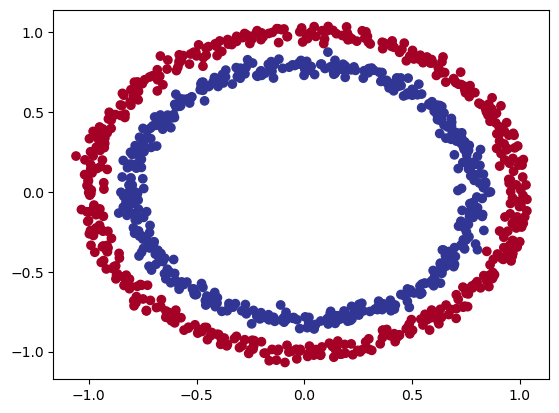

In [122]:
# Visualize with a plot
import matplotlib.pyplot as plt
plt.scatter(x=X[:, 0], 
            y=X[:, 1], 
            c=y, 
            cmap=plt.cm.RdYlBu);

#### 1.1 Input and Output shapes

One of the most common errors in deep learning is shape errors.

Mismatching the shapes of tensors and tensor operations will result in errors in your models.

And there's no surefire way to make sure they won't happen, they will.

What you can do instead is continually familiarize yourself with the shape of the data you're working with.

I like referring to it as input and output shapes.

Ask yourself:

"What shapes are my inputs and what shapes are my outputs?"

Let's find out.

In [123]:
# Check the shapes of our features and labels
X.shape, y.shape

((1000, 2), (1000,))

In [124]:
# View the first example of features and labels
X_sample = X[0]
y_sample = y[0]
print(f"Values for one sample of X: {X_sample} and the same for y: {y_sample}")
print(f"Shapes for one sample of X: {X_sample.shape} and the same for y: {y_sample.shape}")

Values for one sample of X: [0.75424625 0.23148074] and the same for y: 1
Shapes for one sample of X: (2,) and the same for y: ()


#### 1.2 Turn data into tensors and create train and test splits 

We've investigated the input and output shapes of our data, now let's prepare it for being used with PyTorch and for modelling.

Specifically, we'll need to:

1. Turn our data into tensors (right now our data is in NumPy arrays and PyTorch prefers to work with PyTorch tensors).
2. Split our data into training and test sets (we'll train a model on the training set to learn the patterns between X and y and then evaluate those learned patterns on the test dataset).

In [125]:
# Turn data into Tensors 
import torch 
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

# View the first 5 samples 
print(f"First 5 samples of X as tensors:\n{X[:5]}")
print(f"\nFirst 5 samples of y as tensors:\n{y[:5]}")

First 5 samples of X as tensors:
tensor([[ 0.7542,  0.2315],
        [-0.7562,  0.1533],
        [-0.8154,  0.1733],
        [-0.3937,  0.6929],
        [ 0.4422, -0.8967]])

First 5 samples of y as tensors:
tensor([1., 1., 1., 1., 0.])


In [126]:
# Split data into train and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size=0.2, # 20% test, 80% train
                                                    random_state=42) # make the random split reproducible

len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

### 2. Building a model

1. Setting up device agnostic code (so our model can run on CPU or GPU if it's available).
2. Constructing a model by subclassing nn.Module.
3. Defining a loss function and optimizer.
4. Creating a training loop (this'll be in the next section).

In [127]:
# Import Pytorch and create device-agnostic code
import torch
from torch import nn

# Make device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


Create a model that: 
1. Subclasses `nn.Module` 
2. Creates 2 `nn.Linear` layers in the constructor capable of handling the input and output shapes of X and y 
3. Defines a `forward()` method containing the forward pass computation of the model
4. Instantiates the model class and sends it to the target device 

In [128]:
# 1. Constrct a model class that subclasses nn.Module
class CircleModelV0(nn.Module):
    def __init__(self):
        super().__init__()
        # 2. Create 2 nn.Linear layers that feed into each other
        self.layer_1 = nn.Linear(in_features=2, out_features=5) # takes in 2 features and outputs 5 hidden units
        self.layer_2 = nn.Linear(in_features=5, out_features=1) # takes in 5 hidden units and outputs 1 output feature (our prediction)

    # 3. Define a forward method that outlines the forward pass
    def forward(self, x):
        # Return the output of layer_2, a single feature, the same shape as y
        return self.layer_2(self.layer_1(x)) # computation goes through layer_1 first then the output of layer_1 goes through layer_2

# 4. Create an instance of the model and send it to target device
model_0 = CircleModelV0().to(device)
model_0

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

Another method of making the same model can be done by using `nn.Sequential()`. It performs a forward pass computation of the input data through the layers in the order they appear. 

In [129]:
# Replicate CircleModelV0 with nn.Sequential
model_0 = nn.Sequential(
    nn.Linear(in_features=2, out_features=5),
    nn.Linear(in_features=5, out_features=1)
).to(device)

model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.0829, -0.2872],
                      [ 0.4691, -0.5582],
                      [-0.3260, -0.1997],
                      [-0.4252,  0.0667],
                      [-0.6984,  0.6386]], device='cuda:0')),
             ('0.bias',
              tensor([-0.6007,  0.5459,  0.1177, -0.2296,  0.4370], device='cuda:0')),
             ('1.weight',
              tensor([[ 0.0697,  0.3613,  0.0489, -0.1410,  0.1202]], device='cuda:0')),
             ('1.bias', tensor([-0.1213], device='cuda:0'))])

#### Why not always use `nn.Sequential()`?

`nn.Sequential` is fantastic for straight-forward computations, however, as the namespace says, it always runs in sequential order.

So if you'd like something else to happen (rather than just straight-forward sequential computation) you'll want to define your own custom nn.Module subclass.

In [130]:
# Make predictions with the model
untrained_preds = model_0(X_test.to(device))
print(f"Length of predictions: {len(untrained_preds)}, Shape: {untrained_preds.shape}")
print(f"Length of test samples: {len(y_test)}, Shape: {y_test.shape}")
print(f"\nFirst 10 predictions:\n{untrained_preds[:10]}")
print(f"\nFirst 10 test labels:\n{y_test[:10]}")

Length of predictions: 200, Shape: torch.Size([200, 1])
Length of test samples: 200, Shape: torch.Size([200])

First 10 predictions:
tensor([[-0.0337],
        [-0.0309],
        [ 0.0894],
        [-0.0691],
        [ 0.2965],
        [ 0.2967],
        [ 0.1405],
        [ 0.2177],
        [ 0.0805],
        [-0.0284]], device='cuda:0', grad_fn=<SliceBackward0>)

First 10 test labels:
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


#### 2.1 Setup a loss Function and optimizer

Different problem types require different loss functions.

For example, for a regression problem (predicting a number) you might use mean absolute error (MAE) loss.

And for a binary classification problem (like ours), you'll often use binary cross entropy as the loss function.

However, the same optimizer function can often be used across different problem spaces.

For example, the stochastic gradient descent optimizer (SGD, torch.optim.SGD()) can be used for a range of problems, and the same applies to the Adam optimizer (torch.optim.Adam())

In [131]:
# Create a loss function
# loss_fn = nn.BCELoss() # BCELoss = no sigmoid built-in
loss_fn = nn.BCEWithLogitsLoss() # BCEWithLogitsLoss = sigmoid built-in

# Create an optimizer
optimizer = torch.optim.SGD(params=model_0.parameters(), 
                            lr=0.1)

Now let's also create an evaluation metric.There are several evaluation metrics that can be used for classification problems but let's start out with accuracy.

Accuracy can be measured by dividing the total number of correct predictions over the total number of predictions.

In [132]:
# Calculate accuracy (a classification metric)
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item() # torch.eq() calculates where two tensors are equal
    acc = (correct / len(y_pred)) * 100 
    return acc

#### 3. Train the model

Recall: 

1. **Forward pass** - The model goes through all of the training data once, performing its forward() function calculations (model(x_train)).
2. **Calculate the loss** - The model's outputs (predictions) are compared to the ground truth and evaluated to see how wrong they are (loss = loss_fn(y_pred, y_train).
3. **Zero gradients** - The optimizers gradients are set to zero (they are accumulated by default) so they can be recalculated for the specific training step (optimizer.zero_grad()).
4. **Perform backpropagation on the loss** - Computes the gradient of the loss with respect for every model parameter to be updated (each parameter with requires_grad=True). This is known as backpropagation, hence "backwards" (loss.backward()).
5. **Step the optimizer (gradient descent)** - Update the parameters with requires_grad=True with respect to the loss gradients in order to improve them (optimizer.step()).

In [133]:
# View the frist 5 outputs of the forward pass on the test data
y_logits = model_0(X_test.to(device))[:5]
y_logits

tensor([[-0.0337],
        [-0.0309],
        [ 0.0894],
        [-0.0691],
        [ 0.2965]], device='cuda:0', grad_fn=<SliceBackward0>)

However, these numbers are hard to interpret.

We'd like some numbers that are comparable to our truth labels.

To get our model's raw outputs (logits) into such a form, we can use the sigmoid activation function.

In [134]:
# Use sigmoid on model logits
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.4916],
        [0.4923],
        [0.5223],
        [0.4827],
        [0.5736]], device='cuda:0', grad_fn=<SigmoidBackward0>)

They're now in the form of prediction probabilities (I usually refer to these as y_pred_probs), in other words, the values are now how much the model thinks the data point belongs to one class or another.

In our case, since we're dealing with binary classification, our ideal outputs are 0 or 1.

So these values can be viewed as a decision boundary.

In [135]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

We need to keep in mind how are labels are formatted. We need the predicted labels to match the same structure.

In [136]:
# Find the predicted labels by rounding the predicted probabilities
y_preds = torch.round(y_pred_probs)

# Define the labels 
y_pred_labels = torch.round(torch.sigmoid(model_0(X_test.to(device))[:5]))

# Check for equality
print(torch.eq(y_preds.squeeze(), y_pred_labels.squeeze()))

# Get rid of extra dimension
y_preds.squeeze()

tensor([True, True, True, True, True], device='cuda:0')


tensor([0., 0., 1., 0., 1.], device='cuda:0', grad_fn=<SqueezeBackward0>)

#### 3.2 Building a training and testing loop

Lets train for 100 epochs

In [137]:
# Set manual seed
torch.manual_seed(42)

# Set number of epochs
epochs = 100 

# Put data on the target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

# Build training and testing loop
for epoch in range(epochs):
    # Put model in training mode
    model_0.train()

    # 1. Forward pass
    y_logits = model_0(X_train).squeeze() # squeeze to get rid of extra dimension
    y_pred = torch.round(torch.sigmoid(y_logits)) # turn logits into predicted labels

    # 2. Calculate the loss
    loss = loss_fn(y_logits, y_train) # Using nn.BCEWithLogitsLoss works with raw logits
    acc = accuracy_fn(y_true=y_train, y_pred=y_pred)

    # 3. Zero the gradients
    optimizer.zero_grad()

    # 4. Perform backpropagation on the loss with loss.backward()
    loss.backward()

    # 5. Step the optimizer with optimizer.step()
    optimizer.step()

    ### Testing Loop 
    # Put model in evaluation mode
    model_0.eval()
    with torch.inference_mode():
        # 1. Forward pass 
        test_logits = model_0(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

        # 2. Calculate the loss
        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_true=y_test, y_pred=test_pred)
    
    # Print out what's happening every 10 epochs
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Accuracy: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.69796, Accuracy: 51.88% | Test Loss: 0.69440, Test Accuracy: 58.00%
Epoch: 10 | Loss: 0.69590, Accuracy: 51.25% | Test Loss: 0.69306, Test Accuracy: 53.00%
Epoch: 20 | Loss: 0.69490, Accuracy: 51.62% | Test Loss: 0.69255, Test Accuracy: 49.50%
Epoch: 30 | Loss: 0.69435, Accuracy: 51.12% | Test Loss: 0.69236, Test Accuracy: 49.50%
Epoch: 40 | Loss: 0.69401, Accuracy: 50.88% | Test Loss: 0.69232, Test Accuracy: 51.00%
Epoch: 50 | Loss: 0.69378, Accuracy: 50.38% | Test Loss: 0.69234, Test Accuracy: 50.00%
Epoch: 60 | Loss: 0.69362, Accuracy: 50.12% | Test Loss: 0.69239, Test Accuracy: 51.50%
Epoch: 70 | Loss: 0.69351, Accuracy: 50.25% | Test Loss: 0.69246, Test Accuracy: 51.00%
Epoch: 80 | Loss: 0.69342, Accuracy: 49.88% | Test Loss: 0.69254, Test Accuracy: 50.00%
Epoch: 90 | Loss: 0.69336, Accuracy: 50.00% | Test Loss: 0.69263, Test Accuracy: 53.00%


### 4. Make prediction and evaluate the model

From the metrics it looks like our model is random guessing.

How could we investigate this further?

I've got an idea.

The data explorer's motto!

"Visualize, visualize, visualize!"

Let's make a plot of our model's predictions, the data it's trying to predict on and the decision boundary it's creating for whether something is class 0 or class 1.

In [138]:
import requests
from pathlib import Path 

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

# import numpy as np
# import torch
# import matplotlib.pyplot as plt

# # Create a decision boundary visualization function
# def plot_decision_boundary(model, X, y):
#     """
#     Plots decision boundaries of model predicting on X in comparison to y.
#     (Stolen from [mrdbourke/pytorch-deep-learning GitHub repository](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/extras/exercises/02_pytorch_classification_exercises.ipynb))
#     """

#     # Put everything to the CPU for plotting
#     model.to("cpu")
#     X, y = X.to("cpu"), y.to("cpu")

#     # Create a meshgrid of X, y values
#     x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
#     y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1

#     # Define the resolution of the meshgrid
#     h = 0.01 

#     # Generate a grid of points with distance h between them
#     xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arrange(y_min, y_max, h))

#     # Plot decision boundary by predicting the calss of each mesh point
#     # .ravel() flatens the array, np.c_ concatenates column-wise
#     Z = model(torch.from_numpy(np.c_[xx.ravel(), yy.ravel()]).float())

#     # For binary classification with sigmoid output, we use a threshold of 0.5
#     if len(torch.unique(y)) == 2:
#         Z = Z.detach().numpy().reshape(xx.shape)
#         # Plot the contour and training points
#         plt.contourf(xx, yy, Z, cmap=plt.cm.RdBu, alpha=0.7)
#     else: # For multi-class, use the class with the highest probability
#         Z = torch.argmax(Z, dim=1).detach().numpy().reshape(xx.shape)
#         plt.contourf(xx, yy, Z, cmap=plt.cm.RdYlBu, alpha=0.7)

#     # Plot original data points
#     plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdBu, edgecolor='k', s=20)
#     plt.xlim(xx.min(), xx.max())
#     plt.ylim(yy.min(), yy.max())
#     plt.title("Decision Boundary")
#     plt.show()


helper_functions.py already exists, skipping download


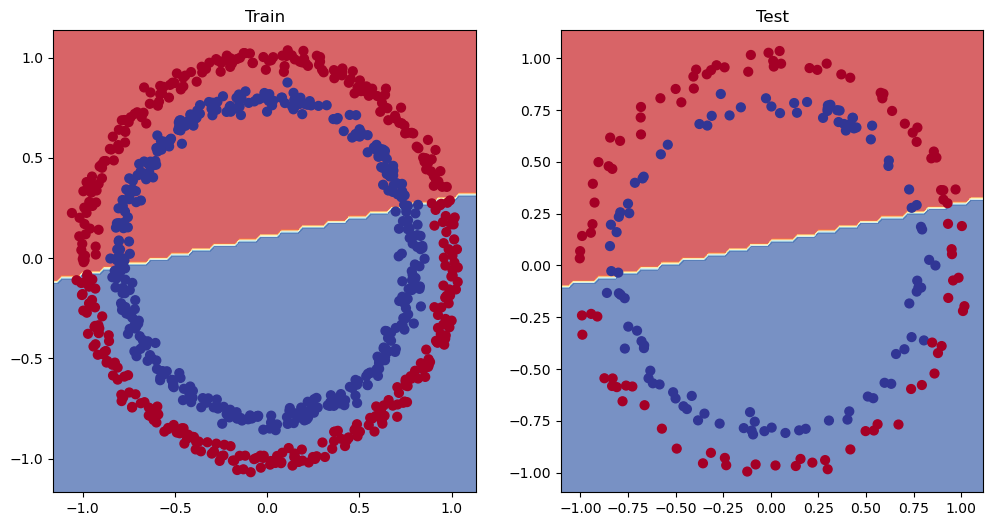

In [139]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)

Oh wow, it seems like we've found the cause of model's performance issue.

It's currently trying to split the red and blue dots using a straight line...

That explains the 50% accuracy. Since our data is circular, drawing a straight line can at best cut it down the middle.

In machine learning terms, our model is underfitting, meaning it's not learning predictive patterns from the data.

How could we improve this?

### 5. Improving a model (from a model perspective)

* Add more layers - gives the model more chances to learn about patterns in the data
* Add more hidden units - More hidden units per layer means a potential increase in learning capabilities of the model. More hidden units are often referred to as making your neural network wider. 
* Fitting for longer (more epochs) - The model might learn more if it had more oppurtunities to look at the data. 
* Changing the activation functions - Some data can't be fit on straight lines, using non-linear activation functions can help in learning non-linear data.
* Change the learning rate - The learning rate of the optimizer decides how much a model should change its parameters each step, too much and the model overcorrects, too little and it does not learn enough. 
* Change the loss function - Different problems require different loss functions. For example, binary cross entropy won't work with a multi-class problem. 
* Transfer learning - Take a pretrained model from a problem domain that is similar to our problem and adjust it to our problem.

These options are all from a model's perspective because they deal directly with the model, rather than the data. 

And because these options are all values we can change, they are considered hyperparameters. 

In [140]:
# we are going to try imporving our model by adding more hidden units: 5 -> 10 
# Increase the numer of layers: 2 -> 3 
# Increase the number of epochs: 100 -> 1000

# Disclaimer: Generally you change one variable at a time to see how it affects the model but for the sake of time, 
# we're going to change all three at once and see what happens for fun. 
class CircleModelV1(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10) # Extra layer 
        self.layer_3 = nn.Linear(in_features=10, out_features=1) # Output layer

    def forward(self, x):
        return self.layer_3(self.layer_2(self.layer_1(x)))

model_1 = CircleModelV1().to(device)
model_1

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

Recreate the loss function and optimzer instance

In [141]:
# loss_fn = nn.BCELoss() # Requires sigmoid on input
loss_fn = nn.BCEWithLogitsLoss() # Does not require sigmoid on input
optimizer = torch.optim.SGD(model_1.parameters(), lr=0.1)

Now we will make the training loop 1000 epochs ratherthan 100 and see if it imporves our model. 

In [142]:
# Set manual seed 
torch.manual_seed(42)

# Set the number of epochs
epochs = 1000

# Build training and testing loop
for epoch in range(epochs):
    ### Training
    # Put model in training mode
    model_1.train()

    # Forward pass 
    y_logits = model_1(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))

    # Calculate loss and accuracy
    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_true=y_train, y_pred=y_pred)

    # Zero gradients
    optimizer.zero_grad()

    # Perform backpropagation
    loss.backward()

    # Step the optimizer
    optimizer.step()

    ### Testing 
    # Put model in evaluation mode
    model_1.eval()
    with torch.inference_mode():
        # Forwad Pass 
        test_logits = model_1(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

        # Calculate loss and accuracy
        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_true=y_test, y_pred=test_pred)

    # Print out what's happening every 100 epochs
    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Accuracy: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.69396, Accuracy: 50.88% | Test Loss: 0.69261, Test Accuracy: 51.00%
Epoch: 100 | Loss: 0.69305, Accuracy: 50.50% | Test Loss: 0.69379, Test Accuracy: 48.00%
Epoch: 200 | Loss: 0.69298, Accuracy: 51.12% | Test Loss: 0.69437, Test Accuracy: 46.00%
Epoch: 300 | Loss: 0.69298, Accuracy: 51.50% | Test Loss: 0.69458, Test Accuracy: 45.00%
Epoch: 400 | Loss: 0.69298, Accuracy: 51.00% | Test Loss: 0.69465, Test Accuracy: 46.00%
Epoch: 500 | Loss: 0.69298, Accuracy: 51.00% | Test Loss: 0.69467, Test Accuracy: 46.00%
Epoch: 600 | Loss: 0.69298, Accuracy: 51.00% | Test Loss: 0.69468, Test Accuracy: 45.50%
Epoch: 700 | Loss: 0.69298, Accuracy: 51.12% | Test Loss: 0.69468, Test Accuracy: 46.00%
Epoch: 800 | Loss: 0.69298, Accuracy: 51.00% | Test Loss: 0.69468, Test Accuracy: 46.00%
Epoch: 900 | Loss: 0.69298, Accuracy: 51.00% | Test Loss: 0.69468, Test Accuracy: 46.00%


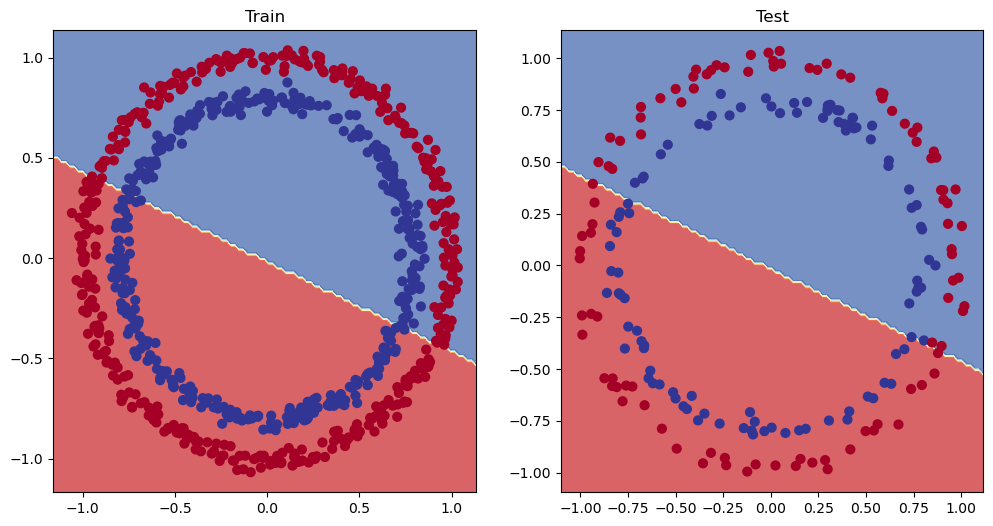

In [143]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_1, X_test, y_test)

Our model is still drawing a straight line between the red and blue dots.

If our model is drawing a straight line, could it model linear data?

#### 5.1 Preparing data to see if our model can model a straight line

In [144]:
# Create some data (same as notebook 01)
weight = 0.7
bias = 0.3
start = 0
end = 1
step = 0.01

# Create data
X_regression = torch.arange(start, end, step).unsqueeze(dim=1)
y_regression = weight * X_regression + bias # linear regression formula

# Check the data
print(len(X_regression))
X_regression[:5], y_regression[:5]

100


(tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400]]),
 tensor([[0.3000],
         [0.3070],
         [0.3140],
         [0.3210],
         [0.3280]]))

In [145]:
# Create train and test splits
train_split = int(0.8 * len(X_regression)) # 80% of data used for training set
X_train_regression, y_train_regression = X_regression[:train_split], y_regression[:train_split]
X_test_regression, y_test_regression = X_regression[train_split:], y_regression[train_split:]

# Check the lengths of each split
print(len(X_train_regression), 
    len(y_train_regression), 
    len(X_test_regression), 
    len(y_test_regression))

80 80 20 20


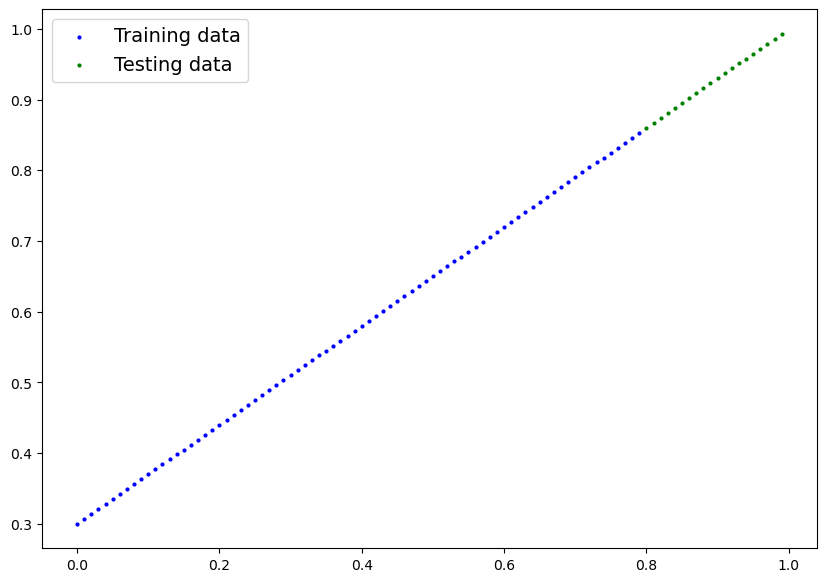

In [146]:
plot_predictions(train_data=X_train_regression,
    train_labels=y_train_regression,
    test_data=X_test_regression,
    test_labels=y_test_regression
);

#### 5.2 Adjusting model_1 to fit a straight line

In [147]:
# Same architecture as model_1 (but using nn.Sequential)
model_2 = nn.Sequential(
    nn.Linear(in_features=1, out_features=10),
    nn.Linear(in_features=10, out_features=10),
    nn.Linear(in_features=10, out_features=1)
).to(device)

model_2

Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=10, bias=True)
  (2): Linear(in_features=10, out_features=1, bias=True)
)

In [148]:
# Loss and optimizer
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(model_2.parameters(), lr=0.1)

In [149]:
# Train the model
torch.manual_seed(42)

# Set the number of epochs
epochs = 1000

# Put data to target device
X_train_regression, y_train_regression = X_train_regression.to(device), y_train_regression.to(device)
X_test_regression, y_test_regression = X_test_regression.to(device), y_test_regression.to(device)

for epoch in range(epochs):
    ### Training 
    # 1. Forward pass
    y_pred = model_2(X_train_regression)
    
    # 2. Calculate loss (no accuracy since it's a regression problem, not classification)
    loss = loss_fn(y_pred, y_train_regression)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    ### Testing
    model_2.eval()
    with torch.inference_mode():
      # 1. Forward pass
      test_pred = model_2(X_test_regression)
      # 2. Calculate the loss 
      test_loss = loss_fn(test_pred, y_test_regression)

    # Print out what's happening
    if epoch % 100 == 0: 
        print(f"Epoch: {epoch} | Train loss: {loss:.5f}, Test loss: {test_loss:.5f}")

Epoch: 0 | Train loss: 0.75982, Test loss: 0.54157
Epoch: 100 | Train loss: 0.09232, Test loss: 0.02196
Epoch: 200 | Train loss: 0.06276, Test loss: 0.00677
Epoch: 300 | Train loss: 0.06701, Test loss: 0.02405
Epoch: 400 | Train loss: 0.06096, Test loss: 0.01940
Epoch: 500 | Train loss: 0.05687, Test loss: 0.01589
Epoch: 600 | Train loss: 0.06076, Test loss: 0.00612
Epoch: 700 | Train loss: 0.05782, Test loss: 0.00939
Epoch: 800 | Train loss: 0.05298, Test loss: 0.00751
Epoch: 900 | Train loss: 0.05539, Test loss: 0.01099


Okay, unlike model_1 on the classification data, it looks like model_2's loss is actually going down.

Let's plot its predictions to see if that's so.

And remember, since our model and data are using the target device, and this device may be a GPU, however, our plotting function uses matplotlib and matplotlib can't handle data on the GPU.

To handle that, we'll send all of our data to the CPU using .cpu() when we pass it to plot_predictions()

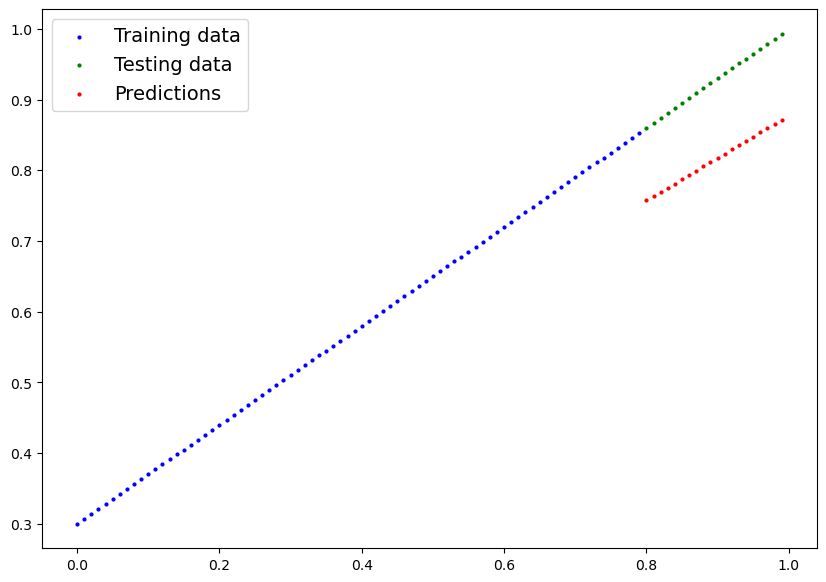

In [150]:
# Turn on evaluation mode
model_2.eval()

# Make predictions (inference)
with torch.inference_mode():
    y_preds = model_2(X_test_regression)

# Plot data and predictions with data on the CPU (matplotlib can't handle data on the GPU)
# (try removing .cpu() from one of the below and see what happens)
plot_predictions(train_data=X_train_regression.cpu(),
                 train_labels=y_train_regression.cpu(),
                 test_data=X_test_regression.cpu(),
                 test_labels=y_test_regression.cpu(),
                 predictions=y_preds.cpu());

Alright, it looks like our model is able to do far better than random guessing on straight lines.

This is a good thing.

It means our model at least has some capacity to learn

### 6. The Missing Piece: non-linearity

#### 6.1 Recreating non-linear data

First, let's recreate the data to start off fresh. We'll use the same setup as before.

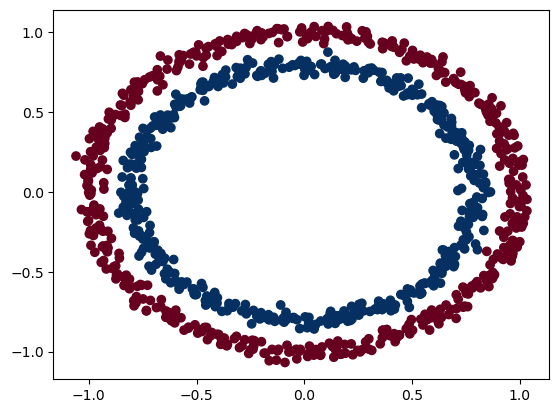

In [151]:
# Make and plot data
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

n_samples = 1000

X, y = make_circles(n_samples=1000,
    noise=0.03,
    random_state=42,
)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdBu);

SPlit data into train and test sets using 80% for training 

In [152]:
import torch
from sklearn.model_selection import train_test_split

# Turn data into tensors
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2,
    random_state=42
)

X_train[:5], y_train[:5]

(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]]),
 tensor([1., 0., 0., 0., 1.]))

#### 6.2 Building a model with non-linearity

PyTorch has a bunch of ready-made non-linear activation functions that do similar but different things.

One of the most common and best performing is ReLU) (rectified linear-unit, torch.nn.ReLU()).

Rather than talk about it, let's put it in our neural network between the hidden layers in the forward pass and see what happens.

In [153]:
# Build model with non-linear activation functions
from torch import nn

class CircleModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10)
        self.layer_3 = nn.Linear(in_features=10, out_features=1)
        self.relu = nn.ReLU() # ReLU = non-linear activation function
    
    def forward(self, x):
        return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x))))) # ReLU after each layer except the output layer
    
model_3 = CircleModelV2().to(device)
model_3

CircleModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [154]:
# Setup loss and optimizer 
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model_3.parameters(), lr=0.1)

#### 6.3 Training a model with non-linearity

In [155]:
### Create training and testing loop 

# Set manual seed
torch.manual_seed(42)
epochs = 1000 

# Put data on the target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

# Build training and testing loop
for epoch in range(epochs):
    ### Training 
    model_3.train()

    # 1. Forward Pass 
    y_logits = model_3(X_train).squeeze() 
    y_pred = torch.round(torch.sigmoid(y_logits))
    
    # 2. Calculate loss and accuracy 
    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_true=y_train, y_pred=y_pred)

    # 3. Zero gradients
    optimizer.zero_grad()

    # 4. Backpropagation
    loss.backward()

    # 5. Step the optimizer 
    optimizer.step()

    ### Testing 
    model_3.eval()
    with torch.inference_mode():
        # 1. Forward pass
        test_logits = model_3(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))
        
        # 2. Calculate loss and accuracy
        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_true=y_test, y_pred=test_pred)

    # Print out what's happening every 100 epochs
    if epoch % 100 == 0: 
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Accuracy: {test_acc:.2f}%")


Epoch: 0 | Loss: 0.69295, Accuracy: 50.00% | Test Loss: 0.69319, Test Accuracy: 50.00%
Epoch: 100 | Loss: 0.69115, Accuracy: 52.88% | Test Loss: 0.69102, Test Accuracy: 52.50%
Epoch: 200 | Loss: 0.68978, Accuracy: 53.37% | Test Loss: 0.68940, Test Accuracy: 55.00%
Epoch: 300 | Loss: 0.68795, Accuracy: 53.00% | Test Loss: 0.68723, Test Accuracy: 56.00%
Epoch: 400 | Loss: 0.68517, Accuracy: 52.75% | Test Loss: 0.68412, Test Accuracy: 56.50%
Epoch: 500 | Loss: 0.68102, Accuracy: 52.75% | Test Loss: 0.67941, Test Accuracy: 56.50%
Epoch: 600 | Loss: 0.67515, Accuracy: 54.37% | Test Loss: 0.67285, Test Accuracy: 56.50%
Epoch: 700 | Loss: 0.66659, Accuracy: 58.38% | Test Loss: 0.66322, Test Accuracy: 59.00%
Epoch: 800 | Loss: 0.65159, Accuracy: 64.00% | Test Loss: 0.64756, Test Accuracy: 67.50%
Epoch: 900 | Loss: 0.62362, Accuracy: 74.00% | Test Loss: 0.62146, Test Accuracy: 79.00%


#### 6.4 Evaluating a model trained with non-linear activation functions 


In [156]:
# Make predictions
model_3.eval()
with torch.inference_mode():
    y_preds = torch.round(torch.sigmoid(model_3(X_test))).squeeze()

y_preds[:10], y[:10] # want preds in same format as truth labels

(tensor([1., 0., 1., 0., 0., 1., 0., 0., 1., 0.], device='cuda:0'),
 tensor([1., 1., 1., 1., 0., 1., 1., 1., 1., 0.]))

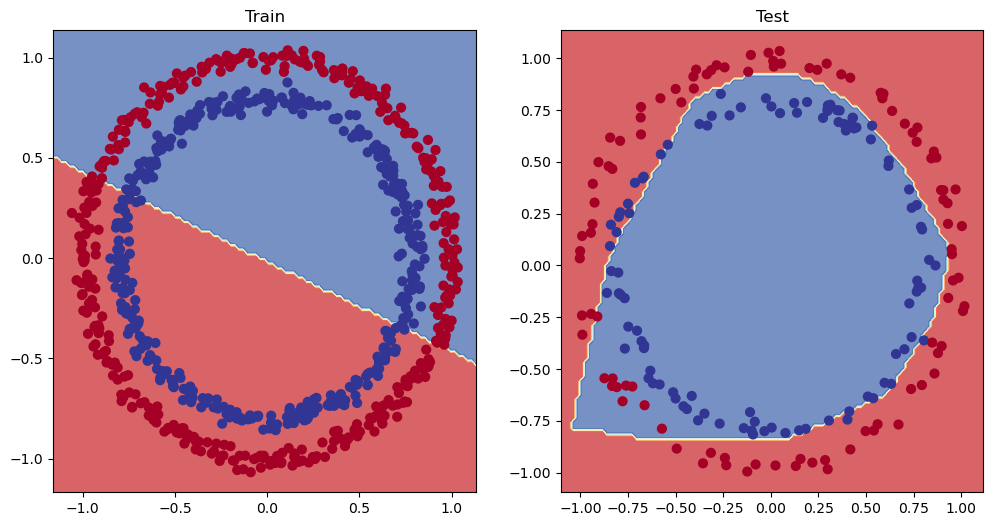

In [157]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train) # model_1 = no non-linearity
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_3, X_test, y_test) # model_3 = has non-linearity

Nice! Not perfect but still far better than before.

### 7. Replicating Non-Linear activation functions

Neural Networks, rather than telling the model what to learn, we give it the tools to discover patterns, in data and patterns on its own. 

These tools are linear and non-linear functions.

In [158]:
# Create a Tensor
A = torch.arange(-10, 10, 1, dtype=torch.float32)
A.dtype

torch.float32

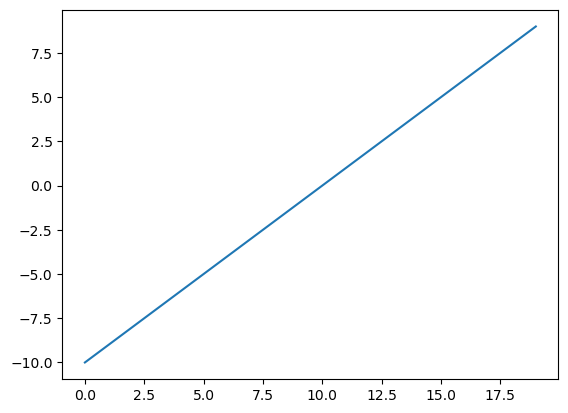

In [159]:
# Visualize the toy tensor
plt.plot(A);

Now let's see how the ReLU activation function influences it.

And instead of using PyTorch's ReLU (torch.nn.ReLU), we'll recreate it ourselves.

The ReLU function turns all negatives to 0 and leaves the positive values as they are.

In [160]:
# Create ReLU activation function
def relu(x:torch.Tensor) -> torch.Tensor:
    return torch.maximum(torch.tensor(0), x) # inputs must be tensors

#Pass toy tensor through ReLU activation function
relu(A)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6., 7.,
        8., 9.])

It looks like our ReLU function worked, all of the negative values are zeros.

Let's plot them.

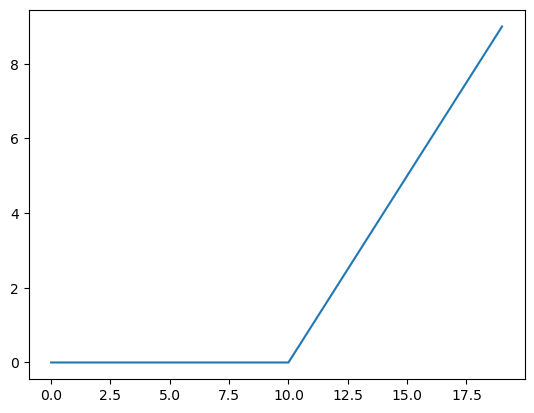

In [161]:
# Plot ReLU activated toy tensor
plt.plot(relu(A));

Nice! That looks exactly like the shape of the ReLU function on the Wikipedia page for ReLU).

How about we try the sigmoid function we've been using?

In [162]:
# Define the non-linear activation function sigmoid 
# Returns a value between 0 and 1
def sigmoid(x:torch.Tensor) -> torch.Tensor:
    return 1 / (1 + torch.exp(-x))

# Pass toy tensor through sigmoid activation function
sigmoid(A)

tensor([4.5398e-05, 1.2339e-04, 3.3535e-04, 9.1105e-04, 2.4726e-03, 6.6929e-03,
        1.7986e-02, 4.7426e-02, 1.1920e-01, 2.6894e-01, 5.0000e-01, 7.3106e-01,
        8.8080e-01, 9.5257e-01, 9.8201e-01, 9.9331e-01, 9.9753e-01, 9.9909e-01,
        9.9966e-01, 9.9988e-01])

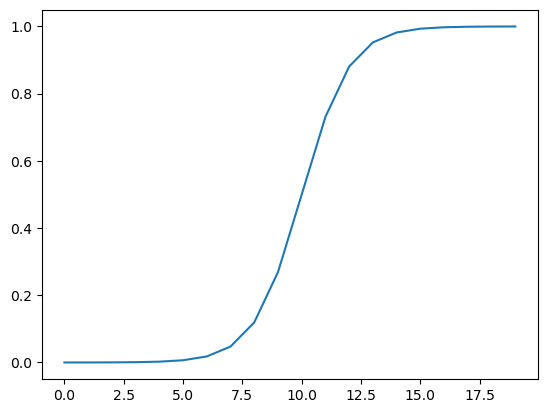

In [163]:
plt.plot(sigmoid(A));

### 8. Putting things together by building a multi-class PyTorch model

Recall a binary classification problem deals with classifying something as one of two options (e.g. a photo as a cat photo or a dog photo) where as a multi-class classification problem deals with classifying something from a list of more than two options (e.g. classifying a photo as a cat a dog or a chicken).

#### 8.1 Creating multi-class classification data

we can leverage Scikit-Learn's make_blobs() method.

This method will create however many classes (using the centers parameter) we want.

Specifically, let's do the following:
1. Create some multi-class data with `make_blobs()`
2. Turn data into tensors (the default of make_blobs() is NumPy arrays)
3. Split data into train and test sets 
4. Visualize the data 

X_blob dtype before: float64, y_blob dtype before: int32
X_blob dtype after: torch.float32, y_blob dtype after: torch.int64
tensor([[-8.4134,  6.9352],
        [-5.7665, -6.4312],
        [-6.0421, -6.7661],
        [ 3.9508,  0.6984],
        [ 4.2505, -0.2815]]) tensor([3, 2, 2, 1, 1])


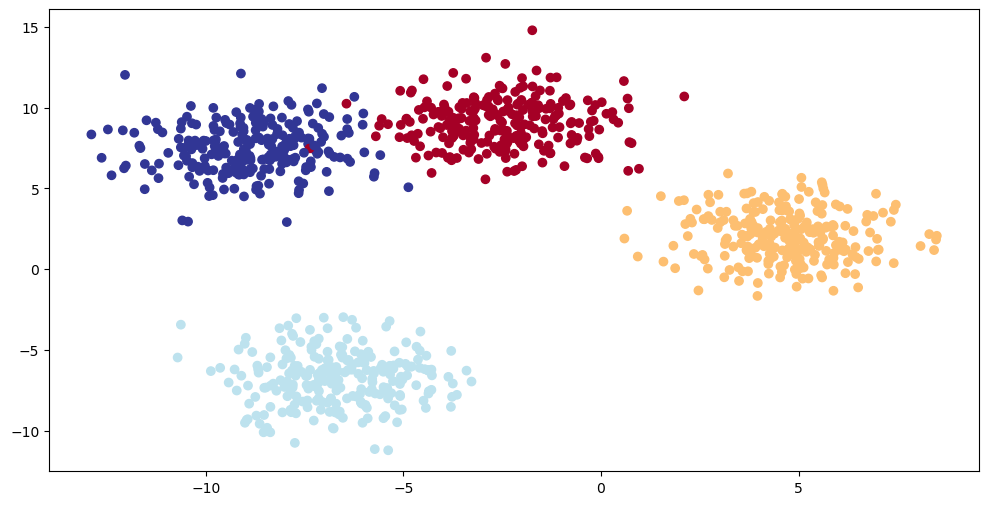

In [164]:
# Import libraries 
import torch 
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

# Set the hyperparameters for data creation 
NUM_CLASSES = 4 
NUM_FEATURES = 2
RANDOM_SEED = 42

# 1. Create data with make_blobs
X_blob, y_blob = make_blobs(
    n_samples=1000, 
    n_features=NUM_FEATURES, # X features
    centers=NUM_CLASSES, # y labels (number of classes)
    cluster_std=1.5, # give the clusters a little shake up
    random_state=RANDOM_SEED 
)

# 2. Turn data into tensors
print(f"X_blob dtype before: {X_blob.dtype}, y_blob dtype before: {y_blob.dtype}")
X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.LongTensor) # for multi-class classification, labels should be long tensors
print(f"X_blob dtype after: {X_blob.dtype}, y_blob dtype after: {y_blob.dtype}")
print(X_blob[:5], y_blob[:5])

# 3. Split data into train and test sets
X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(
    X_blob,
    y_blob, 
    test_size=0.2,
    random_state=RANDOM_SEED
)

# 4. Visualize the data
plt.figure(figsize=(12, 6))
plt.scatter(X_blob[:, 0], X_blob[:, 1], c=y_blob, cmap=plt.cm.RdYlBu);

#### 8.2 Building a multi-class classification model in PyTorch

You might also be starting to get an idea of how flexible neural networks are.

How about we build one similar to model_3 but this is still capable of handling multi-class data?

To do so, let's create a subclass of nn.Module that takes in three hyperparameters:
1. Input_features - the number of X features coming into the model
2. output_features - the ideal numbers of output features we'd like (Equivalent to the NUM_CLASSES)
3. hidden_units - the number of hidden neurons we'd like each hidden layer to use

In [165]:
# Create device agnostic code 
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [166]:
# Build a multi-class classification model 
from torch import nn

# Build a multi-class model 
class BlobModel(nn.Module):
    def __init__(self, input_features:int, out_features:int, hidden_units:int=8):
        """
        Initializes all required hyperparameters for a multi-class classification model.

        Args:
            input_features (int): Number of input features to the model.
            out_features (int): Number of output features (classes) the model should output.
            hidden_units (int): Number of hidden units between layers, Default: 8.
        """
        # Initialize the super class
        super().__init__()

        # Create the layers
        self.linear_layer_stack = nn.Sequential(
            nn.Linear(in_features=input_features, out_features=hidden_units),
            #nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            #nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=out_features)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Performs a forward pass through the model.

        Args:
            x (torch.Tensor): Input data of shape (batch_size, input_features).

        Returns:
            torch.Tensor: Output logits of shape (batch_size, out_features).
        """
        return self.linear_layer_stack(x)

# Create an instance of the model and send it to the target device
model_4 = BlobModel(
    input_features=NUM_FEATURES,
    out_features=NUM_CLASSES,
    hidden_units=8
).to(device)
model_4

BlobModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): Linear(in_features=8, out_features=8, bias=True)
    (2): Linear(in_features=8, out_features=4, bias=True)
  )
)

#### 8.3 Creating a loss function and optimizer for a Multiclass PyTorch model

Since we're working on a multi-class classification problem, we'll use the nn.CrossEntropyLoss() method as our loss function.

And we'll stick with using SGD with a learning rate of 0.1 for optimizing our model_4 parameters.

In [167]:
# Create loss function and optimizer
loss_fn = nn.CrossEntropyLoss() # for multi-class classification
optimizer = torch.optim.SGD(model_4.parameters(), lr=0.1)

#### 8.4 Getting prediction probabilities for a multi-class PyTorch model

In [168]:
# Perform a single forward pass on the data (we'll need to put it to the target device for it to work)
model_4(X_blob_train.to(device))[:5]

tensor([[-1.2708, -0.6492, -1.4741, -0.7048],
        [ 0.2213, -1.5437,  0.0427,  1.1533],
        [ 2.8694,  0.9143,  3.3163,  1.4026],
        [ 1.9568,  0.3127,  2.2246,  1.1325],
        [ 0.5458, -1.2387,  0.4444,  1.1808]], device='cuda:0',
       grad_fn=<SliceBackward0>)

In [169]:
# How many elements in a single prediction sample?
model_4(X_blob_train.to(device))[0].shape, NUM_CLASSES 

(torch.Size([4]), 4)

Wonderful, our model is predicting one value for each class that we have.

Do you remember what the raw outputs of our model are called?

Hint: it rhymes with "frog splits" (no animals were harmed in the creation of these materials).

If you guessed logits, you'd be correct.

So right now our model is outputing logits but what if we wanted to figure out exactly which label is was giving the sample?

As in, how do we go from logits -> prediction probabilities -> prediction labels just like we did with the binary classification problem?

That's where the softmax activation function comes into play.

The softmax function calculates the probability of each prediction class being the actual predicted class compared to all other possible classes.

In [170]:
# Make prediction logits with model 
y_logits = model_4(X_blob_train.to(device))

# Perform softmax calculatuion on logits across dimension 1 to get prediction probabilities
y_pred_probs = torch.softmax(y_logits, dim=1)
print(y_logits[:5])
print(y_pred_probs[:5])

tensor([[-1.2708, -0.6492, -1.4741, -0.7048],
        [ 0.2213, -1.5437,  0.0427,  1.1533],
        [ 2.8694,  0.9143,  3.3163,  1.4026],
        [ 1.9568,  0.3127,  2.2246,  1.1325],
        [ 0.5458, -1.2387,  0.4444,  1.1808]], device='cuda:0',
       grad_fn=<SliceBackward0>)
tensor([[0.1838, 0.3423, 0.1500, 0.3238],
        [0.2199, 0.0376, 0.1839, 0.5585],
        [0.3406, 0.0482, 0.5326, 0.0786],
        [0.3403, 0.0657, 0.4448, 0.1492],
        [0.2526, 0.0424, 0.2283, 0.4767]], device='cuda:0',
       grad_fn=<SliceBackward0>)


After passing the logits through the softmax function, each individual sample now adds to 1 (or very close to).

In [171]:
# Sum the first sample output of the softmax activation function 
torch.sum(y_pred_probs[0])

tensor(1., device='cuda:0', grad_fn=<SumBackward0>)

These prediction probabilities are essentially saying how much the model thinks the target X sample (the input) maps to each class.

Since there's one value for each class in y_pred_probs, the index of the highest value is the class the model thinks the specific data sample most belongs to.

We can check which index has the highest value using torch.argmax().

In [172]:
# Which class does the model think is *most* likely at the index 0 sample?
print(y_pred_probs[0])
print(torch.argmax(y_pred_probs[0]))

tensor([0.1838, 0.3423, 0.1500, 0.3238], device='cuda:0',
       grad_fn=<SelectBackward0>)
tensor(1, device='cuda:0')


#### 8.5 Creating a training and testing loop for a multi-class PyTorch model

let's write a training and testing loop to improve and evaluate our model.The only difference is that we'll be adjusting the steps to turn the model outputs (logits) to prediction probabilities (using the softmax activation function) and then to prediction labels (by taking the argmax of the output of the softmax activation function).

In [173]:
# Define manual seed 
torch.manual_seed(42)

# Set number of epochs
epochs = 1000

# Put data on the target device
X_blob_train, y_blob_train = X_blob_train.to(device), y_blob_train.to(device)
X_blob_test, y_blob_test = X_blob_test.to(device), y_blob_test.to(device)

# Build training and testing loop
for epoch in range(epochs):
    ### Training 
    # 1. Put model in training mode
    model_4.train()

    # 2. Forward Pass
    y_logits = model_4(X_blob_train).squeeze()
    y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1) # for multi-class classification, we use softmax to turn logits into probabilities

    # 3. Calculate loss and accuracy
    loss = loss_fn(y_logits, y_blob_train)
    acc = accuracy_fn(y_true=y_blob_train, y_pred=y_pred) # for multi-class classification, we use argmax to get the predicted class labels

    # 4. Zero gradients
    model_4.zero_grad()

    # 5. Backpropagation
    loss.backward()

    # 6. Step the optimizer
    optimizer.step()

    ### Testing 
    # 1. Put model in evaluation mode
    model_4.eval()
    with torch.inference_mode():
        # 2. Forward pass
        test_logits = model_4(X_blob_test).squeeze()
        test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)
        # 3. Calculate loss and accuracy
        test_loss = loss_fn(test_logits, y_blob_test)
        test_acc = accuracy_fn(y_true=y_blob_test, y_pred=test_pred)

    # Print out what's happening
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Acc: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Acc: {test_acc:.2f}%")        

Epoch: 0 | Loss: 1.04320, Acc: 65.50% | Test Loss: 0.57872, Test Acc: 95.50%
Epoch: 10 | Loss: 0.14395, Acc: 99.12% | Test Loss: 0.13035, Test Acc: 99.00%
Epoch: 20 | Loss: 0.08060, Acc: 99.12% | Test Loss: 0.07217, Test Acc: 99.50%
Epoch: 30 | Loss: 0.05924, Acc: 99.12% | Test Loss: 0.05133, Test Acc: 99.50%
Epoch: 40 | Loss: 0.04892, Acc: 99.00% | Test Loss: 0.04095, Test Acc: 99.50%
Epoch: 50 | Loss: 0.04294, Acc: 99.00% | Test Loss: 0.03486, Test Acc: 99.50%
Epoch: 60 | Loss: 0.03910, Acc: 99.00% | Test Loss: 0.03082, Test Acc: 99.50%
Epoch: 70 | Loss: 0.03644, Acc: 99.00% | Test Loss: 0.02801, Test Acc: 99.50%
Epoch: 80 | Loss: 0.03448, Acc: 99.12% | Test Loss: 0.02589, Test Acc: 99.50%
Epoch: 90 | Loss: 0.03301, Acc: 99.12% | Test Loss: 0.02425, Test Acc: 99.50%
Epoch: 100 | Loss: 0.03186, Acc: 99.12% | Test Loss: 0.02296, Test Acc: 99.50%
Epoch: 110 | Loss: 0.03094, Acc: 99.12% | Test Loss: 0.02185, Test Acc: 99.50%
Epoch: 120 | Loss: 0.03018, Acc: 99.12% | Test Loss: 0.02097, T

#### 8.6 Making and evaluating predictions with a PyTorch multi-class model

In [174]:
# Make predictions
model_4.eval()
with torch.inference_mode():
    y_logits = model_4(X_blob_test)

# View the first 10 predictions
y_logits[:10]

tensor([[  6.1061,  18.9145, -22.9513, -14.6941],
        [  9.5636, -23.8525,   5.8459,  17.7009],
        [ -8.3947, -21.8660,  30.5418,  17.0872],
        [  2.1302,  14.6642, -13.7764, -11.2612],
        [ 13.2069,   3.9312, -21.4802,  -3.6413],
        [ 10.8450, -29.6240,   8.5452,  22.0351],
        [ -9.3785, -15.7041,  27.1018,  12.4430],
        [ 11.9256,  -3.3341, -13.8528,   1.9576],
        [ -7.8602, -31.8076,  37.6316,  24.6310],
        [ 12.1850,  -0.6222, -16.3821,  -0.1230]], device='cuda:0')

In [175]:
# Turn predicted logits in prediction probabilities
y_pred_probs = torch.softmax(y_logits, dim=1)

# Turn prediction probabilities into prediction labels
y_preds = y_pred_probs.argmax(dim=1)

# Compare first 10 model preds and test labels
print(f"Predictions: {y_preds[:10]}\nLabels: {y_blob_test[:10]}")
print(f"Test accuracy: {accuracy_fn(y_true=y_blob_test, y_pred=y_preds)}%")

Predictions: tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0], device='cuda:0')
Labels: tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0], device='cuda:0')
Test accuracy: 99.5%


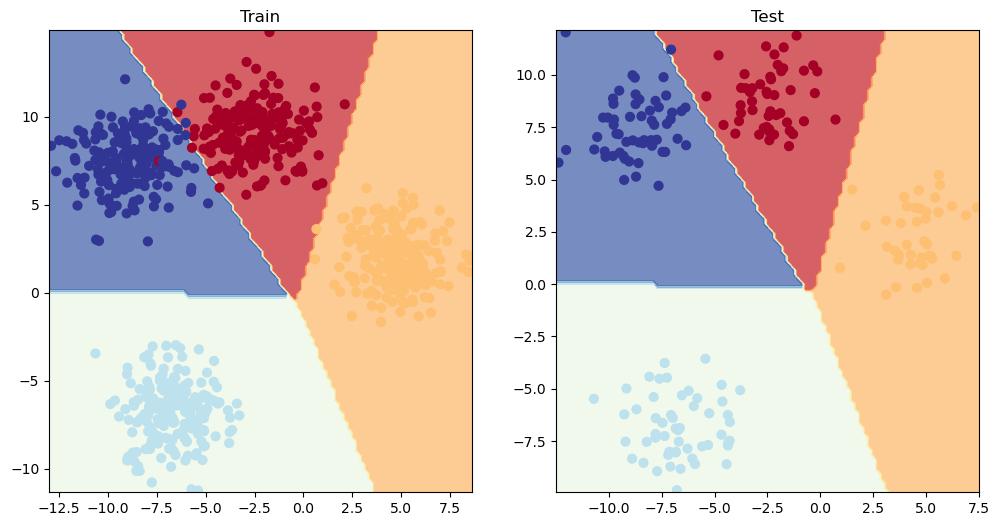

In [176]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_4, X_blob_train, y_blob_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_4, X_blob_test, y_blob_test)

In [ ]:
try:
    from torchmetrics import Accuracy
except:
    !pip install torchmetrics==0.9.3 # this is the version we're using in this notebook (later versions exist here: https://torchmetrics.readthedocs.io/en/stable/generated/CHANGELOG.html#changelog)
    from torchmetrics import Accuracy

# Setup metric and make sure it's on the target device
torchmetrics_accuracy = Accuracy(task='multiclass', num_classes=4).to(device)

# Calculate accuracy
torchmetrics_accuracy(y_preds, y_blob_test)

tensor(0.9950, device='cuda:0')